# **Datalab II Sprints 2025 - 2026**
**Plaats:** De Haagse Hogenschool, ADS & AI<br>
**Auteurs:** M. Kilinc, L. Hoetink J. Wolthuis, S. Slingerland, L. van Hamersveld<br>
**Groep:** B2 <br>
**Coach:** Onur Tezel <br>
**Datum:** 10/03/2026


| Naam  | Studentnummer |
|-------|---------------|
| Lucas v. H.| 25076116      |
| Sandro| 25154370      |
| Memhet| 25135007      |
| Julius| 25090216      |
| Lucas H.| 25108263      |

---
### Inhoudsopgave
1. [Sprint 2](#1)
2. [Sprint 3](#2)
3. [Sprint 4](#3)



---
<a id='1'></a>
# **Sprint 2**

---
<a id='1'></a>
### 1. Imports & Configuratie

In [2]:
# Imports
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from scipy.stats import pearsonr, f_oneway

---
<a id='2'></a>
### 2. Data laden & beschrijven van Relaties
Hier laden we de SQL-gegevens verder in en geven we een overzicht van de database. We beschrijven de verschillende tabellen, hun kolommen en de onderlinge relaties, zodat een duidelijk beeld ontstaat van de structuur en organisatie van de data.

---
### 2.1 Gebruik van de Kaggle API
We gebruiken de Kaggle API om de data lokaal op te slaan en dit hoeft slechts eenmalig te gebeuren.<br>Download de API-sleutel uit onze GitHub-repository en plaats deze in de map C:\Users\<Jouw_gebruikersnaam>\.kaggle. <br>

Raadpleeg voor verdere instructies de officiële documentatie op https://www.kaggle.com/docs/api.<br>
Verwijder eventueel het # in het script, voer de pip install en de data-import uit en je bent klaar om de data lokaal te gebruiken.


In [3]:
# %pip install kaggle 
import kaggle 
import os
import shutil

kaggle.api.authenticate()
# Download to /tmp since current directory is read-only in remote environments
kaggle.api.dataset_download_files("hugomathien/soccer", path='/tmp', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/hugomathien/soccer


In [4]:
# Maak een verbinding met de SQLite-database "database.sqlite"
# Try local path first, then /tmp as fallback for remote environments
db_path = "./database.sqlite" if os.path.exists("./database.sqlite") else "/tmp/database.sqlite"
connection = sqlite3.connect(db_path)

# Voer een SQL-query uit om alle gegevens uit de tabel 'Match' op te halen, het resultaat wordt ingelezen als pandas DataFrame
df = pd.read_sql("""
    
    SELECT *  
        FROM Match 
                 
    """, 
    connection)

player_attributes = pd.read_sql("""
    
    SELECT *  
        FROM Player_Attributes 
                 
    """, 
    connection)

player = pd.read_sql("""
    
    SELECT *  
        FROM Player 
                 
    """, 
    connection)

In [5]:
# Herbruikbare functie om een SQL-query uit te voeren en het resultaat te tonen
def voer_query_uit(query, conn, toon=True):
    """Voert een SQL-query uit en geeft het resultaat terug als DataFrame.
    
    Parameters:
        query (str): De SQL-query om uit te voeren.
        conn: De database connectie.
        toon (bool): Als True wordt het DataFrame getoond. Standaard True.
    """
    df = pd.read_sql(query, conn)
    if toon:
        display(df)
    return df

---
### 2.2 Relaties tussen tabellen

In [6]:
# Elke tabel inladen en de kolomnamen weergeven
tabel_namen = ['Country', 'League', 'Match', 'Team', 'Team_Attributes', 'Player', 'Player_Attributes']

for tabel in tabel_namen:
    df_tabel = pd.read_sql(f"SELECT * FROM {tabel} LIMIT 3", connection)
    print(f"Tabel: {tabel}")
    print(f"Kolommen: {list(df_tabel.columns)}")
    print()

Tabel: Country
Kolommen: ['id', 'name']

Tabel: League
Kolommen: ['id', 'country_id', 'name']

Tabel: Match
Kolommen: ['id', 'country_id', 'league_id', 'season', 'stage', 'date', 'match_api_id', 'home_team_api_id', 'away_team_api_id', 'home_team_goal', 'away_team_goal', 'home_player_X1', 'home_player_X2', 'home_player_X3', 'home_player_X4', 'home_player_X5', 'home_player_X6', 'home_player_X7', 'home_player_X8', 'home_player_X9', 'home_player_X10', 'home_player_X11', 'away_player_X1', 'away_player_X2', 'away_player_X3', 'away_player_X4', 'away_player_X5', 'away_player_X6', 'away_player_X7', 'away_player_X8', 'away_player_X9', 'away_player_X10', 'away_player_X11', 'home_player_Y1', 'home_player_Y2', 'home_player_Y3', 'home_player_Y4', 'home_player_Y5', 'home_player_Y6', 'home_player_Y7', 'home_player_Y8', 'home_player_Y9', 'home_player_Y10', 'home_player_Y11', 'away_player_Y1', 'away_player_Y2', 'away_player_Y3', 'away_player_Y4', 'away_player_Y5', 'away_player_Y6', 'away_player_Y7', 'aw

### 2.2.1 Beschrijving inhoud kolomen
#### Country
| Kolomnaam | Key type | Beschrijving |
| :--- | :--- | :--- |
| id | Primairy key| Uniek ID van het land |
| name | – | Naam van het land |

---

#### League
| Kolomnaam | Key type | Beschrijving |
| :--- | :--- | :--- |
| id | Primairy key | Uniek ID van de competitie |
| country_id | Foreign key (Country.id) | Koppelt de competitie aan een land |
| name | – | Naam van de competitie |

---

#### Team
| Kolomnaam | Key type| Beschrijving |
| :--- | :--- | :--- |
| id | Primairy key | Uniek rij-ID in de database |
| team_api_id | Functional key | Uniek ID dat als key wordt gebruikt in Match en Team_Attributes |
| team_fifa_api_id | – | FIFA-specifiek ID van het team |
| team_long_name | – | Volledige naam van de club|
| team_short_name | – | Afkorting van de club naam|

---

#### Team_Attributes
| Kolomnaam | Key type | Beschrijving |
| :--- | :--- | :--- |
| id | Primairy key | Uniek rij-ID |
| team_api_id | Foreign key (Team.team_api_id) | Koppelt de attributen aan een team |
| date | – | Datum |
| buildUpPlaySpeed | – | Hoe snel een team de aanval opbouwt|
| buildUpPlayPassing | – | Passstijl in de opbouwfase kort, gemengd of lang |
| chanceCreationShooting | – | Mate waarin een team kansen creëert via schoten |
| defencePressure  | – | Hoeveel druk een team zet op de tegenstander bij balverlies |
| defenceAggression | – | Hoe agressief een team verdedigt|

---

#### Player
| Kolomnaam | Key type  | Beschrijving |
| :--- | :--- | :--- |
| id | Primairy key| Uniek rij-ID |
| player_api_id | Functional key | Uniek ID dat als key wordt gebruikt in Match en Player_Attributes |
| player_name | – | Volledige naam van de speler |
| birthday | – | Geboortedatum van de speler |
| height | – | Lengte in centimeters |
| weight | – | Gewicht in pounds |

---

#### Player_Attributes
| Kolomnaam | Key type | Beschrijving |
| :--- | :--- | :--- |
| id` | Primairy key | Uniek rij-ID |
| player_api_id | Foreign key (Player.player_api_id) | Koppelt de attributen aan een speler |
| date | – | Datum  |
| overall_rating | – | Algemene FIFA-rating van de speler op datum |
| preferred_foot | – | Voorkeursbeen (links/rechts) |
| finishing | – | Hoe accuraat de speler schiet op doel |
| sprint_speed | – | Sprintsnelheid speler |
| stamina | – | Uithoudingsvermogen tijdens wedstrijd |
| strength | – | Fysieke kracht speler |

---

#### Match
| Kolomnaam | Key type| Beschrijving |
| :--- | :--- | :--- |
| id | Primairy key | Uniek ID van de wedstrijd |
| country_id | Foreign key (Country.id) | Land waarin de wedstrijd gespeeld werd |
| league_id | Foreign key (League.id)| Competitie waarin de wedstrijd gespeeld werd |
| season | – | Seizoen van de wedstrijd |
| date | – | Datum van de wedstrijd |
| home_team_api_id | Foreign key (Team.team_api_id) | Thuisspelende team |
| away_team_api_id | Foreign key  (Team.team_api_id) | Uitspelende team |
| home_team_goal | – | Aantal doelpunten gescoord thuisteam |
| away_team_goal | – | Aantal doelpunten gescoord uitteam |
| home_player_1 t/m home_player_11 | Foreign key (Player.player_api_id) | Basisspelers van het thuisteam |
| away_player_1 t/m away_player_11 | Foreign key (Player.player_api_id) | Basisspelers van het uitteam |

---

### 2.2.2 Overzicht tabel van key identifiers in deze dataset

- Primairy key: Een uniek ID dat elke rij in een tabel identificeert. Geen twee rijen kunnen dezelfde waarde hebben.
- Functional key: Een kolom die in de praktijk als koppelsleutel wordt gebruikt tussen tabellen, maar niet de officiële primaire sleutel is.
- Foreign key : Een kolom die verwijst naar de primaire of functionele sleutel van een andere tabel, om de twee tabellen met elkaar te verbinden.


| Tabel | Primairy key| Functional key |
| :--- | :--- | :--- |
| Country | id | – |
| League | id | country_id |
| Team | id | team_api_id |
| Team_Attributes | id | team_api_id |
| Player | id | player_api_id |
| Player_Attributes | id | player_api_id |
| Match | id | home_team_api_id, away_team_api_id, home/away_player_1–11, country_id, league_id |

---

### 2.3 Toelichting relaties en key identifiers
De database bestaat uit zeven tabellen die onderling met elkaar verbonden zijn via primairy key en foreign keys. <br> 
Alle relaties zijn one-to-many relaties, dit betekent dat een record in een tabel gekoppeld kan zijn aan meerdere records in een andere tabel.<br> 

De tabel Country vormt de basis van de database. Elke competitie in de tabel League is gekoppeld aan een land via de relatie League.country_id - Country.id. Daarnaast is de tabel League verbonden met de tabel Match via Match.league_id - League.id. <br>
Hierdoor wordt elke wedstrijd aan een specifieke competitie gekoppeld.

De tabel Team is op twee manieren verbonden met Match, via Match.home_team_api_id - Team.team_api_id voor het thuisteam en via Match.away_team_api_id - Team.team_api_id voor het uitteam. <br> 

De kenmerken en tactische eigenschappen van teams zijn opgeslagen in de tabel Team_Attributes, die gekoppeld is via Team_Attributes.team_api_id - Team.team_api_id. <br> 

De tabel Player is gekoppeld aan Match via de kolommen home_player_1 tot en met away_player_11, waarbij elke kolom verwijst naar Player.player_api_id. De beoordelingen en fysieke eigenschappen van spelers zijn opgeslagen in Player_Attributes, gekoppeld via Player_Attributes.player_api_id - Player.player_api_id.


---

In [7]:
# Toon de eerste vijf rijen van het DataFrame om een overzicht van de data te krijgen
display(df.head())

,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


---

In [8]:
# Onderzoeken welke tabelnamen er in deze database zitten
# Query om alle tabelnamen uit de database te halen

# 'sqlite_master' is een interne systeemtabel van SQLite die metadata bevat
# over de database, zoals alle tabellen, indices, views en triggers

query_tables = """
    SELECT name 
    FROM sqlite_master 
    WHERE type='table';
"""

# Sla de resultaten op als een pandas DataFrame
tables_df = pd.read_sql(query_tables, connection)

# Printen van de resultaten
print("Tabellnamen in de database:")
display(tables_df)

Tabellnamen in de database:


,name
0,sqlite_sequence
1,Player_Attributes
2,Player
3,Match
4,League
5,Country
6,Team
7,Team_Attributes


In [9]:
# SQL-query om alle teams te selecteren waarvan de lange of korte naam die 'AZ' bevat
query_az_teams = """
    SELECT * FROM Team 
    WHERE team_long_name LIKE '%AZ%' 
       OR team_short_name LIKE '%AZ%';
"""
# Sla resultaat van query op als pandas DataFrame 
az_teams_df = pd.read_sql(query_az_teams, connection)

# Printen van de resultaten
print("Gevonden teams met 'AZ' in de naam:")
display(az_teams_df) 

Gevonden teams met 'AZ' in de naam:


,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
0,20516,8543,46,Lazio,LAZ
1,26563,10229,1906,AZ,ALK


---
<a id='3'></a>
### 3. Club identifiers bepalen
Hier bepalen we de belangrijkste identiefiers van onze gekozen club (AZ) zodat we hier later in de notebook gemakkelijk naar kunnen zoeken.

In [10]:
# Club opzoeken & identifiers opslaan
def haal_club_ids_op(club_naam, conn):

    """ Haalt de team_api_id en team_fifa_api_id op voor een gegeven clubnaam.

    Description: De functie probeert eerst een exacte match te vinden op de kolom 
    'team_long_name'. Indien geen resultaat wordt gevonden, wordt er 
    een bredere zoekopdracht uitgevoerd met behulp van een LIKE-query.

    Parameters: 
    - club_naam : str
    - conn : sqlite3.Connection 

    Returns:
    - tuple: Een tuple met (team_api_id, team_fifa_api_id). """
        

    query_exact = "SELECT team_api_id, team_fifa_api_id, team_long_name FROM Team WHERE team_long_name = ?;"
    df = pd.read_sql_query(query_exact, conn, params=(club_naam,))

    if df.empty:
        query_breed = "SELECT team_api_id, team_fifa_api_id, team_long_name FROM Team WHERE team_long_name LIKE ?;"
        df = pd.read_sql_query(query_breed, conn, params=(f"%{club_naam}%",))

    if not df.empty:
        api_id, fifa_id = df.iloc[0]['team_api_id'], df.iloc[0]['team_fifa_api_id']
        print(f"ID's gevonden voor: {df.iloc[0]['team_long_name']}")
        return api_id, fifa_id

    print(f"Club '{club_naam}' niet gevonden.")

    return None, None

AZ_API_ID, AZ_FIFA_ID = haal_club_ids_op("AZ", connection)

print(f"AZ_API_ID: {AZ_API_ID} | AZ_FIFA_ID: {AZ_FIFA_ID}")

ID's gevonden voor: AZ
AZ_API_ID: 10229 | AZ_FIFA_ID: 1906


---

In [11]:
# Query om statistieken op te halen via het specifieke AZ_API_ID
query_az_stats = """

SELECT * FROM Team_Attributes 
WHERE team_api_id = ? 
ORDER BY date DESC;
"""
# Sla resultaat van query op als pandas DataFrame 
df_az_stats = pd.read_sql_query(query_az_stats, connection, params=(int(AZ_API_ID),))

# Printen eerste 5 rijen van de resultaten
df_az_stats.head()

,id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,...,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,118,1906,10229,2015-09-10 00:00:00,50,Balanced,46.0,Normal,58,Mixed,...,50,Normal,Organised,50,Medium,61,Press,55,Normal,Cover
1,117,1906,10229,2014-09-19 00:00:00,52,Balanced,38.0,Normal,46,Mixed,...,52,Normal,Free Form,50,Medium,61,Press,55,Normal,Cover
2,116,1906,10229,2013-09-20 00:00:00,62,Balanced,NaN,Little,40,Mixed,...,52,Normal,Organised,50,Medium,65,Press,59,Normal,Cover
3,115,1906,10229,2012-02-22 00:00:00,46,Balanced,NaN,Little,36,Mixed,...,52,Normal,Organised,60,Medium,65,Press,59,Normal,Cover
4,114,1906,10229,2011-02-22 00:00:00,45,Balanced,NaN,Little,31,Short,...,66,Normal,Organised,60,Medium,50,Press,65,Normal,Cover


---
<a id='4'></a>
### 4. Ranglijst seizoen
Voor de verdere analyses hebben we ervoor gekozen om gegevens uit het seizoen 2015/2016 te onderzoeken. De onderstaande code richt zich op de Eredivisie-klassering van dit seizoen. Hierbij worden alle wedstrijdgegevens en uitslagen van de Nederlandse Eredivisie uit 2015/2016 opgehaald uit de database, gesorteerd in chronologische volgorde.

In [12]:
def haal_eredivisie_wedstrijden_op(seizoen, conn):
    """Haalt alle wedstrijden op van de Nederlandse Eredivisie voor een gegeven seizoen.

    Parameters:
    - seizoen : str - Bijvoorbeeld '2015/2016'
    - conn : sqlite3.Connection

    Returns:
    - DataFrame met wedstrijden inclusief teams en doelpunten."""

    query = """

SELECT 
    Match.date,
    Match.season,
    HT.team_long_name AS thuisteam,
    AT.team_long_name AS uitteam,
    Match.home_team_goal AS thuis_doelpunten,
    Match.away_team_goal AS uit_doelpunten

FROM Match
JOIN League ON Match.league_id = League.id
JOIN Country ON League.country_id = Country.id
JOIN Team AS HT ON Match.home_team_api_id = HT.team_api_id
JOIN Team AS AT ON Match.away_team_api_id = AT.team_api_id
WHERE Country.name = 'Netherlands' AND Match.season = ?
ORDER BY Match.date;
"""

    # Sla resultaat van query op als pandas DataFrame
    df = pd.read_sql_query(query, conn, params=(seizoen,))

    # Printen van de resultaten
    print("Eerste 5 wedstrijden van dit seizoen:")
    display(df.head())
    return df

df_eredivisie = haal_eredivisie_wedstrijden_op('2015/2016', connection)

Eerste 5 wedstrijden van dit seizoen:


,date,season,thuisteam,uitteam,thuis_doelpunten,uit_doelpunten
0,2015-08-08 00:00:00,2015/2016,Roda JC Kerkrade,Heracles Almelo,3,1
1,2015-08-08 00:00:00,2015/2016,Feyenoord,FC Utrecht,3,2
2,2015-08-09 00:00:00,2015/2016,AZ,Ajax,0,3
3,2015-08-09 00:00:00,2015/2016,Willem II,Vitesse,1,1
4,2015-08-11 00:00:00,2015/2016,SC Heerenveen,De Graafschap,3,1


---
### 4.1 Ranglijst

In [13]:
def bereken_ranglijst(df):
    """Berekent de eindranglijst op basis van wedstrijduitslagen.

    Parameters:
    - df : DataFrame - Wedstrijden met kolommen thuisteam, uitteam,
      thuis_doelpunten en uit_doelpunten.

    Returns:
    - DataFrame met de eindstand gesorteerd op punten."""

    # Bepaal wie de wedstrijd wint en deel de punten/resultaten uit
    condities = [
        df['thuis_doelpunten'] > df['uit_doelpunten'],  # Thuisteam wint
        df['thuis_doelpunten'] == df['uit_doelpunten']  # Gelijkspel
    ]

    # Punten en resultaten voor thuisploeg
    df['punten_thuis'] = np.select(condities, [3, 1], default=0)
    df['winst_thuis'] = np.select(condities, [1, 0], default=0)
    df['gelijk_thuis'] = np.select(condities, [0, 1], default=0)
    df['verlies_thuis'] = np.select(condities, [0, 0], default=1)

    # Punten en resultaten voor uitploeg
    df['punten_uit'] = np.select(condities, [0, 1], default=3)
    df['winst_uit'] = np.select(condities, [0, 0], default=1)
    df['gelijk_uit'] = np.select(condities, [0, 1], default=0)
    df['verlies_uit'] = np.select(condities, [1, 0], default=0)

    # Verzamel alle behaalde thuisstatistieken per team
    thuis_tabel = df.groupby('thuisteam')[['punten_thuis', 'winst_thuis', 'gelijk_thuis', 'verlies_thuis']].sum().reset_index()
    thuis_tabel.columns = ['Team', 'Punten', 'Gewonnen', 'Gelijk', 'Verloren']

    # Verzamel alle behaalde uitstatistieken per team
    uit_tabel = df.groupby('uitteam')[['punten_uit', 'winst_uit', 'gelijk_uit', 'verlies_uit']].sum().reset_index()
    uit_tabel.columns = ['Team', 'Punten', 'Gewonnen', 'Gelijk', 'Verloren']

    # Voeg thuis en uit samen, tel het totaal op en maak de ranglijst
    alle_statistieken = pd.concat([thuis_tabel, uit_tabel])
    eindstand = alle_statistieken.groupby('Team')[['Punten', 'Gewonnen', 'Gelijk', 'Verloren']].sum().reset_index()

    # Sorteer op punten van hoog naar laag
    eindstand = eindstand.sort_values(by='Punten', ascending=False).reset_index(drop=True)

    # Pas index start aan naar 0 zodat de nummer 1 niet index 0 heeft
    eindstand.index = eindstand.index + 1

    print("Eindstand Eredivisie Seizoen:")
    display(eindstand)
    return eindstand

eindstand = bereken_ranglijst(df_eredivisie)

Eindstand Eredivisie Seizoen:


,Team,Punten,Gewonnen,Gelijk,Verloren
1,PSV,84,26,6,2
2,Ajax,82,25,7,2
3,Feyenoord,63,19,6,9
4,AZ,59,18,5,11
5,FC Utrecht,53,15,8,11
6,Heracles Almelo,51,14,9,11
7,FC Groningen,50,14,8,12
8,PEC Zwolle,48,14,6,14
9,N.E.C.,46,13,7,14
10,Vitesse,46,12,10,12


---
### 4.2 Visualisatie Ranglijst

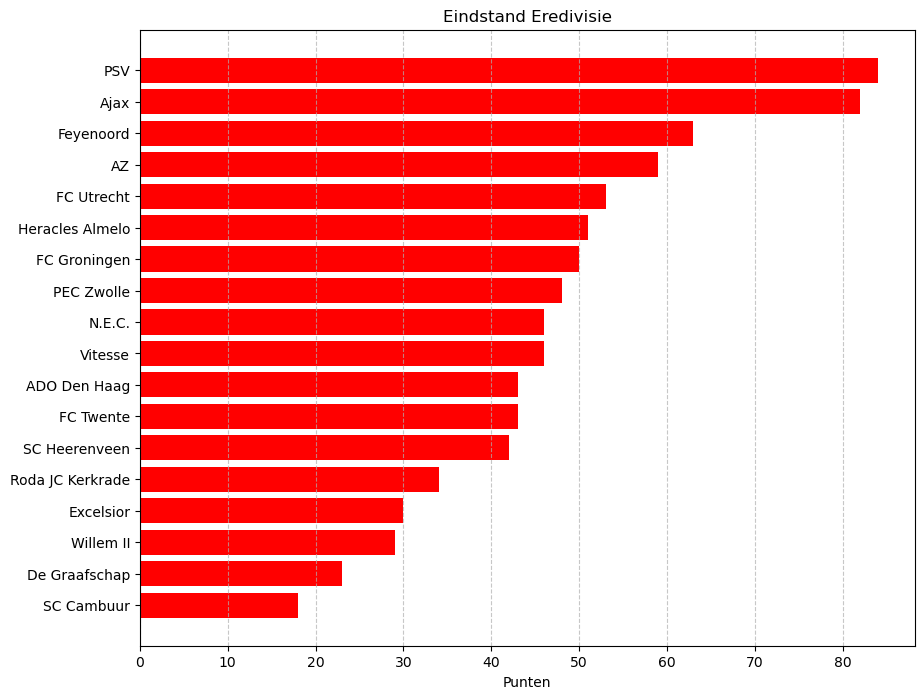

In [14]:
def visualiseer_ranglijst(eindstand):
    """Maakt een horizontaal staafdiagram van de eindstand.

    Parameters:
    - eindstand : DataFrame - Eindstand met kolommen 'Team' en 'Punten'."""

    # Data voor visualisatie plotten
    df_plot = eindstand.sort_values(by='Punten', ascending=True)

    # Maak de visualisatie
    plt.figure(figsize=(10, 8))
    plt.barh(df_plot['Team'], df_plot['Punten'], color='red')

    # Defineer label x-as en titel van de grafiek
    plt.xlabel('Punten')
    plt.title('Eindstand Eredivisie')

    # Toon grafiek
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

visualiseer_ranglijst(eindstand)

---

<a id='5'></a>
### 5. Classes

---

In [15]:
class Club():
    """
        Description: 
            Deze class representeert een voetbalclub. Het bevat informatie over de club en DataFrames voor spelers en wedstrijden.
        
        Attributes:
            team_id: id van de club.
            team_name: De naam van de club.
            matches_df: DataFrame met wedstrijden van de club.
            
         Methods:
            load_matches(matches_df): 
                Laadt wedstrijden van de club als DataFrame.
            get_season_matches(season): 
                Haalt wedstrijden van een bepaald seizoen.
            calculate_season_stats(season): 
                Berekent statistieken voor het team voor het gegeven seizoen.
            get_player_stats(): 
                Berekent gemiddelde en categorische statistieken voor spelers van het team.
    """
    
    def __init__(self, team_id, team_name):
        """
            Description:
                De constructor van de Club class.
                
            Args:
                team_id: id van de club.
                team_name: De naam van de club.
                
            Returns:
                None
            
        """
        self.team_id = team_id
        self.team_name = team_name
        self.matches_df = pd.DataFrame()
        
    def load_matches(self, matches_df):
        """
            Description:
                Laadt alle wedstrijden van deze club uit een matches DataFrame.
                
            Args:
                matches_df: Een DataFrame met alle wedstrijden.
                
            Returns:
                None
        """
        club_matches = matches_df[(matches_df['home_team_api_id'] == self.team_id) | (matches_df['away_team_api_id'] == self.team_id)].copy()
        self.matches_df = club_matches
        
    def get_season_matches(self, season):
        """
            Description:
                Haalt alle wedstrijden van een bepaald seizoen.
                
            Args:
                season: Het seizoen (bijv. '2015/2016').
                
            Returns:
                DataFrame met wedstrijden van dat seizoen.
        """
        return self.matches_df[self.matches_df['season'] == season]
    
    def calculate_season_stats(self, season=None):
        """
            Description:
                Berekent statistieken voor het team in een bepaald seizoen.
                
            Args:
                season: Het seizoen (optioneel). Als None, alle seizoenen.
                
            Returns:
                Dictionary met statistieken.
        """
        if season:
            matches = self.get_season_matches(season)
        else:
            matches = self.matches_df
        
        if len(matches) == 0:
            return {}
        
        wins = len(matches[
            ((matches['home_team_api_id'] == self.team_id) & (matches['home_team_goal'] > matches['away_team_goal'])) |
            ((matches['away_team_api_id'] == self.team_id) & (matches['away_team_goal'] > matches['home_team_goal']))
        ])
        
        draws = len(matches[matches['home_team_goal'] == matches['away_team_goal']])
        losses = len(matches) - wins - draws
        
        goals_for = matches[matches['home_team_api_id'] == self.team_id]['home_team_goal'].sum() + \
                    matches[matches['away_team_api_id'] == self.team_id]['away_team_goal'].sum()
        
        goals_against = matches[matches['home_team_api_id'] == self.team_id]['away_team_goal'].sum() + \
                        matches[matches['away_team_api_id'] == self.team_id]['home_team_goal'].sum()
        
        points = (wins * 3) + (draws * 1)
        
        return {
            'club': self.team_name,
            'wins': wins,
            'draws': draws,
            'losses': losses,
            'goals_for': goals_for,
            'goals_against': goals_against,
            'goal_difference': goals_for - goals_against,
            'points': points,
            'matches_played': len(matches)
        }

    def get_player_stats(self):
        """
            Description:
                Berekent gemiddelde en categorische statistieken voor spelers van het team.
                
            Returns:
                DataFrame met numerieke gemiddelden en categorische waarde tellingen.
        """
        matches = self.matches_df
            
        # Vind alle spelers die in dit seizoen hebben gespeeld in deze club
        home_players = matches[matches['home_team_api_id'] == self.team_id][['home_player_1', 'home_player_2', 'home_player_3', 'home_player_4', 'home_player_5', 'home_player_6', 'home_player_7', 'home_player_8', 'home_player_9', 'home_player_10', 'home_player_11']]
        away_players = matches[matches['away_team_api_id'] == self.team_id][['away_player_1', 'away_player_2', 'away_player_3', 'away_player_4', 'away_player_5', 'away_player_6', 'away_player_7', 'away_player_8', 'away_player_9', 'away_player_10', 'away_player_11']]     
        
        player_ids = pd.concat([home_players.stack(), away_players.stack()]).unique()
        
        global player_attributes
        
        def get_player_stats(player_id):
            player_data = player_attributes[player_attributes['player_api_id'] == player_id].drop(columns=['date'])
            return player_data.iloc[0]
        
        total_stats = []
        
        for player_id in player_ids:
            stats = get_player_stats(player_id)
            total_stats.append(stats)
        
        stats_df = pd.DataFrame(total_stats)
        
        # Bereken numerieke gemiddelden
        numeric_stats = stats_df.select_dtypes(include=[np.number]).mean().round(2).to_dict()
        
        # Bereken categorische waardetellers en breid uit naar aparte kolommen
        categorical_cols = stats_df.select_dtypes(include=['object']).columns
        categorical_stats = {}
        
        for col in categorical_cols:
            value_counts = stats_df[col].value_counts().to_dict()
            for value, count in value_counts.items():
                categorical_stats[f'{col}_{value}'] = count
        
        # Combineer resultaten in één rij
        result = {**numeric_stats, **categorical_stats}
        result_df = pd.DataFrame([result])
        
        global player
        
        # Add player names by merging stats_df onto player dataframe with right join
        stats_df = player[['player_api_id', 'player_name']].merge(stats_df, on='player_api_id', how='right')
        
        return (result_df.drop(columns=['id', 'player_api_id','player_fifa_api_id'], errors='ignore'), stats_df.drop(columns=['id', 'player_api_id','player_fifa_api_id'], errors='ignore'))
        
class Research():
    """
        Description:
            Deze class bevat methoden voor het uitvoeren van onderzoek en analyses op de club data.
        
        Methods:
            season_correlation_analysis(club, season): 
                Voert een correlatieanalyse uit op de performance van het team in een seizoen.
                
            get_season_ranking(matches_df, season, league_id):
                Geeft de ranglijst van alle teams voor een seizoen.    
    """
    
    def __init__(self, connection):
        self.connection = connection
          
    def season_correlation_analysis(self, season):
        """
            Description:
                Voert een correlatieanalyse uit op de performance van het team in een seizoen.
                Combineert team statistieken met speler statistieken en berekent correlaties met punten.
                
            Args:
                season: Het seizoen om te analyseren.
                
            Returns:
                DataFrame met correlaties gesorteerd op absolute correlatiewaarde.
        """
        global matches, teams
        
        season_matches = matches[matches['season'] == season].copy()
        
        data = []
        
        for team in season_matches['home_team_api_id'].unique():
            club = Club(team_id=team, team_name=teams.loc[teams['team_api_id'] == team, 'team_long_name'].values[0])
            club.load_matches(matches)
            
            # Teamstatistieken ophalen
            team_stats = club.calculate_season_stats(season)
            
            # Spelerstatistieken ophalen
            player_stats_df = club.get_player_stats()
            player_stats = player_stats_df.iloc[0].to_dict() if not player_stats_df.empty else {}
            
            # Combineer team- en spelerstatistieken in één rij
            combined_stats = {**team_stats, **player_stats}
            data.append(combined_stats)
        
        # Converteer naar DataFrame
        analysis_df = pd.DataFrame(data)
        
        # Bereken correlaties met punten
        if 'points' not in analysis_df.columns:
            print("'points' column not found in data")
            return pd.DataFrame()
        
        correlations = []
        numeric_cols = analysis_df.select_dtypes(include=[np.number]).columns
        
        for col in numeric_cols:
            if col != 'points':  # Correleer punten niet met zichzelf
                # Sla kolommen met nul-variantie over (voorkomt deling door nul waarschuwing)
                if analysis_df[col].std() == 0:
                    continue
                
                corr_value = round(analysis_df[col].corr(analysis_df['points']), 2)
                if pd.notna(corr_value):
                    correlations.append({
                        'variable': col,
                        'correlation_with_points': corr_value
                    })
        
        # Creëer correlatie DataFrame gesorteerd op absolute correlatie
        correlation_df = pd.DataFrame(correlations).sort_values(
            'correlation_with_points', 
            ascending=False, 
            key=abs
        ).reset_index(drop=True)
        
        # Verwijder irrelevante variabelen die meer direct uit punten zijn berekend
        irrelevant_vars = ['wins', 'goal_difference', 'goals_for', 'goals_against', 'matches_played', 'draws', 'losses']
        return correlation_df[~correlation_df['variable'].isin(irrelevant_vars)]
    
    def get_season_ranking(self, matches_df, season, league_id=None):
        """
            Description:
                Geeft de ranglijst van alle teams voor een bepaald seizoen en competitie.
                
            Args:
                matches_df: DataFrame met alle wedstrijden.
                season: Het seizoen om te analyseren.
                league_id: Optionele league_id.
                
            Returns:
                DataFrame met ranglijst gesorteerd op punten.
        """
        season_matches = matches_df[matches_df['season'] == season].copy()
        
        global teams
        
        if league_id:
            season_matches = season_matches[season_matches['league_id'] == league_id]
        
        if season_matches.empty:
            print(f'Geen matches gevonden voor season {season}.')
            return pd.DataFrame()
        
        season_stats_list = []
        
        for team in season_matches['home_team_api_id'].unique():
            club = Club(team_id=team, team_name=teams.loc[teams['team_api_id'] == team, 'team_long_name'].values[0])
            club.load_matches(matches_df)
            stats = club.calculate_season_stats(season)
            season_stats_list.append(stats)
        
        season_stats = pd.DataFrame(season_stats_list)
        ranking_df = season_stats.sort_values('points', ascending=False).reset_index(drop=True)
        
        return ranking_df
    
    def sql_to_df(self, query):
        """
            Description:
                Voert een SQL-query uit op de database en retourneert het resultaat als een DataFrame.
                
            Args:
                query: De SQL-query om uit te voeren.
                
            Returns:
                DataFrame met queryresultaten.
        """
        return pd.read_sql_query(query, self.connection)

---

In [16]:
# Laden van AZ data en opslaan met nieuwe class
az = Club(team_id=AZ_API_ID, team_name='AZ')

az.load_matches(df)

az_avg_stats, az_total_stats = az.get_player_stats()

display(az_avg_stats)
display(az_total_stats)

,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,...,gk_positioning,gk_reflexes,preferred_foot_right,preferred_foot_left,attacking_work_rate_medium,attacking_work_rate_high,attacking_work_rate_low,defensive_work_rate_medium,defensive_work_rate_high,defensive_work_rate_low
0,71.14,73.91,55.34,51.63,58.78,65.75,52.76,62.25,57.32,50.37,...,15.8,15.97,51,25,49,25,2,53,14,9


,player_name,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,finishing,heading_accuracy,short_passing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,Sergio Romero,76.0,76.0,right,medium,medium,11.0,14.0,12.0,38.0,...,42.0,16.0,14.0,11.0,15.0,76.0,67.0,81.0,73.0,82.0
1,Gill Swerts,64.0,64.0,right,medium,high,60.0,43.0,69.0,62.0,...,51.0,47.0,55.0,59.0,57.0,8.0,10.0,6.0,14.0,7.0
2,Kew Jaliens,63.0,63.0,right,medium,medium,47.0,41.0,48.0,57.0,...,46.0,39.0,58.0,70.0,64.0,14.0,5.0,9.0,13.0,14.0
3,Hector Moreno,79.0,79.0,left,medium,high,50.0,33.0,77.0,74.0,...,59.0,63.0,82.0,84.0,85.0,12.0,15.0,14.0,9.0,10.0
4,Sebastien Pocognoli,75.0,75.0,left,high,medium,77.0,50.0,63.0,69.0,...,58.0,58.0,74.0,76.0,78.0,10.0,9.0,8.0,15.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,Pantelis Hatzidiakos,61.0,74.0,right,medium,medium,46.0,20.0,58.0,55.0,...,28.0,40.0,62.0,59.0,60.0,9.0,14.0,11.0,11.0,9.0
72,Levi Garcia,64.0,78.0,left,medium,medium,60.0,50.0,22.0,62.0,...,65.0,30.0,18.0,21.0,22.0,10.0,10.0,10.0,9.0,10.0
73,Marko Vejinovic,74.0,76.0,right,low,medium,78.0,60.0,71.0,84.0,...,76.0,76.0,58.0,63.0,52.0,7.0,15.0,9.0,14.0,16.0
74,Kees Luijckx,66.0,66.0,right,medium,medium,56.0,48.0,72.0,57.0,...,56.0,64.0,64.0,66.0,65.0,14.0,6.0,13.0,11.0,10.0


---
<a id='2'></a>
# **Sprint 3**

---

### 3. Data Exploration met SQL
Ter referentie: op basis van het vorige notebook hebben we alle databaserelaties visueel in kaart gebracht met een dbdiagram.io-schema.

![Alternatieve tekst](Diagram.png)

------
### 3.1 Aantal gespeelde wedstrijden per seizoen

In [17]:
AZ_API_ID = 10229
AZ_FIFA_ID = 1906

# Query
query  = f"""

SELECT season, COUNT(*) AS aantal_gespeelde_wedstrijden
FROM Match

WHERE home_team_api_id = {AZ_API_ID}
   OR away_team_api_id = {AZ_API_ID}

GROUP BY season
ORDER BY season;

"""
# Opslaan data uit query in DataFrame en tonen
df = voer_query_uit(query, connection)

# Printen samenvatting ondervindingen 
print(f'AZ alkmaar is sinds seizoen 1998/1999 onafgebroken in de Eredivisie een speelde: {df["aantal_gespeelde_wedstrijden"].sum()} wedstrijden')


,season,aantal_gespeelde_wedstrijden
0,2008/2009,34
1,2009/2010,34
2,2010/2011,34
3,2011/2012,34
4,2012/2013,34
5,2013/2014,34
6,2014/2015,34
7,2015/2016,34


AZ alkmaar is sinds seizoen 1998/1999 onafgebroken in de Eredivisie een speelde: 272 wedstrijden


---
### 3.2 Aantal gespeelde wedstrijden kalender jaar 2010

In [18]:
# In deze query wordt gebruik gemaakt van strftime (string format time) 
# Deze functie converteert datum en tijdobjecten naar leesbare tekenreeksen op basis van specifieke opmaakcodes

# Query
query  = f"""

SELECT season, COUNT(*) AS gespeelde_wedstrijden
FROM Match

WHERE (home_team_api_id = {AZ_API_ID} OR 
away_team_api_id = {AZ_API_ID})
AND strftime('%Y', date) = '2010' 

GROUP BY season
ORDER BY season;

"""

# Opslaan data uit query in DataFrame en tonen
df = voer_query_uit(query, connection)

# Printen samenvatting ondervindingen 
print(f'In het kalender jaar 2010 speelde AZ: {df["gespeelde_wedstrijden"].sum()} wedstrijden')

,season,gespeelde_wedstrijden
0,2009/2010,16
1,2010/2011,18


In het kalender jaar 2010 speelde AZ: 34 wedstrijden


---
### 3.3 Punten per seizoen & eindklassering

In [19]:
# Ik gebruik hier UNION ALL deze functie stapelt rijen van tabellen op elkaar inclusief dubbele records
Eredivisie_id = 13274

query = f"""
SELECT
    T.team_long_name AS Team,
    S.season,
    SUM(S.punten) AS totaal_punten
FROM (
    SELECT
        season,
        home_team_api_id AS team_api_id,
        CASE
            WHEN home_team_goal > away_team_goal THEN 3
            WHEN home_team_goal = away_team_goal THEN 1
            ELSE 0
        END AS punten
    FROM Match
    WHERE league_id = {Eredivisie_id}

    UNION ALL

    SELECT
        season,
        away_team_api_id AS team_api_id,
        CASE
            WHEN away_team_goal > home_team_goal THEN 3
            WHEN away_team_goal = home_team_goal THEN 1
            ELSE 0
        END AS punten

    FROM Match
    WHERE league_id = {Eredivisie_id}
) AS S

JOIN Team AS T ON S.team_api_id = T.team_api_id
GROUP BY S.season, S.team_api_id, T.team_long_name
ORDER BY S.season DESC, totaal_punten DESC;
"""

# Opslaan data uit query in DataFrame
df_2 = voer_query_uit(query, connection, toon=False)

# DataFrame eerste 10 rijen want er zijn veel rijen in dit DataFrame
display(df_2.head(10))

,Team,season,totaal_punten
0,PSV,2015/2016,84
1,Ajax,2015/2016,82
2,Feyenoord,2015/2016,63
3,AZ,2015/2016,59
4,FC Utrecht,2015/2016,53
5,Heracles Almelo,2015/2016,51
6,FC Groningen,2015/2016,50
7,PEC Zwolle,2015/2016,48
8,Vitesse,2015/2016,46
9,N.E.C.,2015/2016,46


---
### 3.4 Eindklassering AZ per seizoen

In [20]:
# Rangschikking per seizoen bepalen op basis van totaal punten
df_2['klassering'] = df_2.groupby('season')['totaal_punten'].rank(ascending=False, method='min').astype(int)

# Eindklassering van AZ Alkmaar per seizoen weergeven
df_az_klassering = df_2[df_2['Team'] == 'AZ'][['season', 'totaal_punten', 'klassering']].sort_values('season').reset_index(drop=True)
display(df_az_klassering)

# Printen samenvatting ondervindingen
print(f'AZ Alkmaar eindigde gemiddeld op plaats {df_az_klassering["klassering"].mean():.1f} in de Eredivisie')

,season,totaal_punten,klassering
0,2008/2009,80,1
1,2009/2010,62,5
2,2010/2011,59,4
3,2011/2012,65,4
4,2012/2013,39,10
5,2013/2014,47,8
6,2014/2015,62,3
7,2015/2016,59,4


AZ Alkmaar eindigde gemiddeld op plaats 4.9 in de Eredivisie


---
## **4. Onderzoeken Teameigenschappen**

---
### 4.1 Teameigenschappen samenvoegen

In [21]:
# query om teameigenschappen te selecteren en te groeperen op teamnaam
query = """
SELECT
    T.team_long_name AS Team,
    AVG(TA.buildUpPlaySpeed)            AS buildUpPlaySpeed,
    AVG(TA.buildUpPlayDribbling)        AS buildUpPlayDribbling,
    AVG(TA.buildUpPlayPassing)          AS buildUpPlayPassing,
    AVG(TA.chanceCreationPassing)       AS chanceCreationPassing,
    AVG(TA.chanceCreationCrossing)      AS chanceCreationCrossing,
    AVG(TA.chanceCreationShooting)      AS chanceCreationShooting,
    AVG(TA.defencePressure)             AS defencePressure,
    AVG(TA.defenceAggression)           AS defenceAggression,
    AVG(TA.defenceTeamWidth)            AS defenceTeamWidth
FROM Team_Attributes AS TA
JOIN Team AS T ON TA.team_api_id = T.team_api_id
GROUP BY T.team_long_name;
"""

# Opslaan data uit query in DataFrame
df_attrs = voer_query_uit(query, connection, toon=False)

# Samenvoegen met het punten DataFrame op teamnaam
df_merged = pd.merge(df_2, df_attrs, on='Team', how='inner')

# DataFrame met alle teameigenschappen en punten per team 
display(df_merged.head(10))

# Print grote van de samengevoegde DataFrame
print(f'Samengevoegd DataFrame: {len(df_merged)} rijen, {len(df_merged.columns)} kolommen')

,Team,season,totaal_punten,klassering,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
0,PSV,2015/2016,84,1,52.333333,39.0,38.333333,50.166667,54.500000,54.000000,43.833333,41.500000,48.833333
1,Ajax,2015/2016,82,2,35.166667,41.5,33.833333,50.666667,58.500000,49.666667,59.833333,53.833333,54.333333
2,Feyenoord,2015/2016,63,3,43.833333,36.5,44.833333,48.500000,52.333333,43.166667,41.666667,44.000000,42.833333
3,AZ,2015/2016,59,4,51.666667,42.0,42.666667,54.333333,52.000000,55.333333,50.000000,55.333333,57.166667
4,FC Utrecht,2015/2016,53,5,50.833333,44.5,50.000000,48.000000,56.666667,55.166667,42.166667,48.666667,42.000000
5,Heracles Almelo,2015/2016,51,6,46.166667,45.5,40.333333,43.666667,54.833333,58.000000,44.333333,51.000000,42.000000
6,FC Groningen,2015/2016,50,7,47.166667,37.0,41.500000,51.000000,59.000000,52.333333,44.833333,43.666667,48.500000
7,PEC Zwolle,2015/2016,48,8,49.666667,38.0,48.000000,54.666667,50.000000,55.333333,54.000000,54.666667,59.000000
8,Vitesse,2015/2016,46,9,42.000000,47.5,39.000000,53.833333,46.000000,59.833333,45.166667,50.166667,52.333333
9,N.E.C.,2015/2016,46,9,44.000000,42.0,42.800000,45.200000,51.800000,50.800000,38.600000,45.600000,44.000000


Samengevoegd DataFrame: 143 rijen, 13 kolommen


---
### 4.2 Visualisaties maken

In [22]:
# Berekent totaal punten per team via een SQL-query, optioneel gefilterd op competitie
def bereken_punten_per_team(conn, league_id=None):
    """Berekent het totaal aantal punten per team via een SQL-query.
    
    Parameters:
        conn: De database connectie.
        league_id (int): Optioneel filter op competitie ID.
    """
    where = f"WHERE league_id = {league_id}" if league_id else ""

    query = f"""
    SELECT team_api_id, SUM(punten) AS points
    FROM (
        SELECT home_team_api_id AS team_api_id,
               CASE WHEN home_team_goal > away_team_goal THEN 3
                    WHEN home_team_goal = away_team_goal THEN 1
                    ELSE 0 END AS punten
        FROM Match {where}

        UNION ALL

        SELECT away_team_api_id AS team_api_id,
               CASE WHEN away_team_goal > home_team_goal THEN 3
                    WHEN away_team_goal = home_team_goal THEN 1
                    ELSE 0 END AS punten
        FROM Match {where}
    )
    GROUP BY team_api_id
    """
    return pd.read_sql(query, conn)


---

In [23]:
# Totaal punten per team berekenen via zelfgedefinieerde functie
points_df = bereken_punten_per_team(connection)

# Numerieke teameigenschappen gemiddeld over alle beschikbare records per team
attrs_num_q = """
SELECT team_api_id,
       AVG(buildUpPlaySpeed)      AS buildUpPlaySpeed,
       AVG(buildUpPlayPassing)    AS buildUpPlayPassing,
       AVG(chanceCreationPassing) AS chanceCreationPassing,
       AVG(defencePressure)       AS defencePressure
FROM Team_Attributes
GROUP BY team_api_id
"""
# Opslaan data uit query in DataFrame
attrs_num_df = voer_query_uit(attrs_num_q, connection, toon=False)

In [24]:
# Categoriale klassen uit het meest recente record per team halen
attrs_cat_q = """
SELECT ta.team_api_id,
       ta.buildUpPlaySpeedClass,
       ta.defencePressureClass
FROM Team_Attributes ta
JOIN (
    SELECT team_api_id, MAX(date) AS max_date
    FROM Team_Attributes
    GROUP BY team_api_id
) latest
  ON ta.team_api_id = latest.team_api_id
 AND ta.date        = latest.max_date
"""

# Opslaan data uit query in DataFrame
attrs_cat_df = voer_query_uit(attrs_cat_q, connection, toon=False).drop_duplicates(subset=['team_api_id'])

# Alles samenvoegen tot één dataset per team
data_2b = (points_df.merge(attrs_num_df, on='team_api_id', how='inner').merge(attrs_cat_df, on='team_api_id', how='left'))

# Variabelen die we willen analyseren
num_vars = ['buildUpPlaySpeed', 'buildUpPlayPassing', 'chanceCreationPassing', 'defencePressure']
cat_vars = ['buildUpPlaySpeedClass', 'defencePressureClass']

---

In [25]:
# Functies voor visualisatie en statistische analyse van numerieke en categorische variabelen versus punten
def plot_numeric_vs_points(data: pd.DataFrame, col: str) -> dict:
    sub = data[[col, 'points']].dropna()

    # Te weinig data om een betrouwbare correlatie te berekenen
    if len(sub) < 5 or sub[col].nunique() < 2:
        return {}

    # Pearson-correlatie: meet lineair verband en significantie
    r, p = pearsonr(sub[col], sub['points'])

    ax = sns.regplot(data=sub, x=col, y='points',
                     scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'})
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.set_title(f'Invloed van {col} op punten\nr = {r:.2f}  |  p = {p:.3g}', fontweight='bold')
    ax.set_ylabel('Totaal punten', fontsize=12)
    sns.despine()
    plt.tight_layout()
    plt.show()

    return {'variabele': col, 'r': r, 'p': p, 'n': len(sub)}


def plot_categorical_vs_points(data: pd.DataFrame, col: str) -> dict:
    sub = data[[col, 'points']].dropna()

    # Categorieën met minder dan 5 teams weggooien, anders is ANOVA niet betrouwbaar
    counts = sub[col].value_counts()
    sub = sub[sub[col].isin(counts[counts >= 5].index)]
    if sub[col].nunique() < 2:
        return {}

    # ANOVA: kijkt of het gemiddeld aantal punten significant verschilt per categorie
    groups = [g['points'].values for _, g in sub.groupby(col)]
    F, p = f_oneway(*groups)

    # Sorteren op mediaan zodat de hoogste categorie links staat
    order = sub.groupby(col)['points'].median().sort_values(ascending=False).index
    ax = sns.boxplot(data=sub, x=col, y='points', order=order)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}'))
    ax.set_title(f'Puntenverdeling per {col}\nANOVA p = {p:.3g}', fontweight='bold')
    ax.set_ylabel('Totaal punten', fontsize=12)
    plt.xticks(rotation=20)
    sns.despine()
    plt.tight_layout()
    plt.show()

    return {'variabele': col, 'anova_F': F, 'p': p, 'n': len(sub)}

---

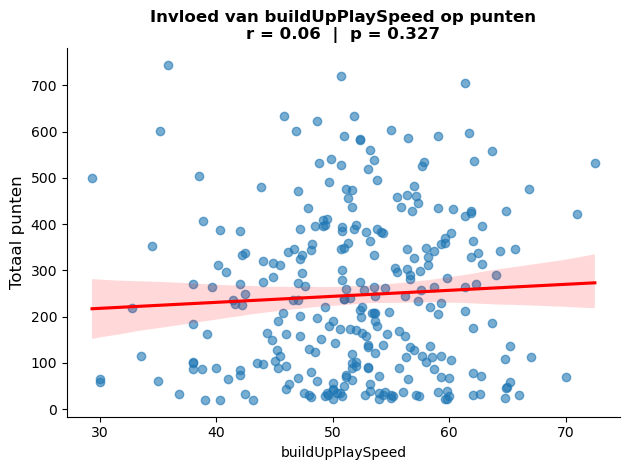

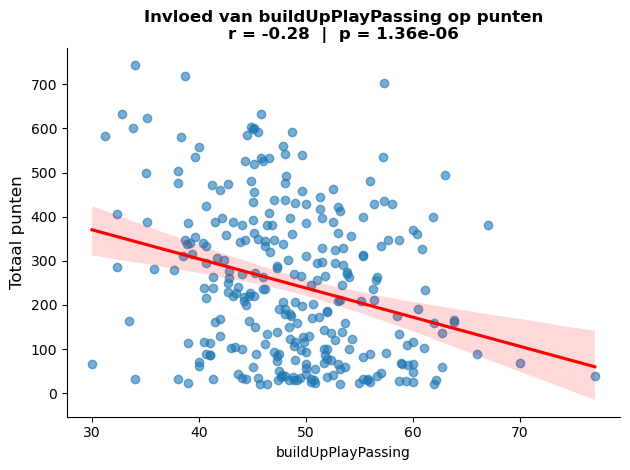

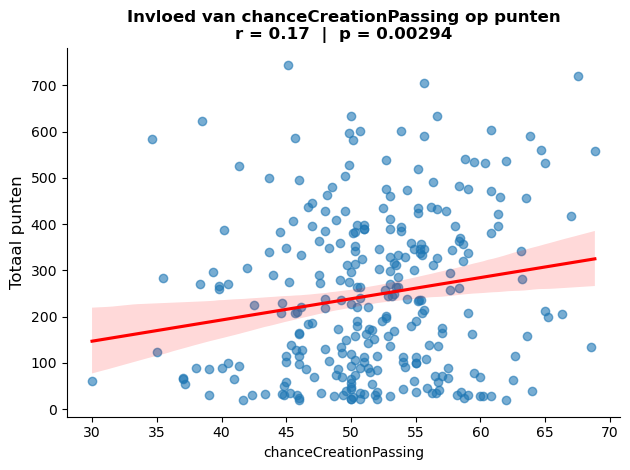

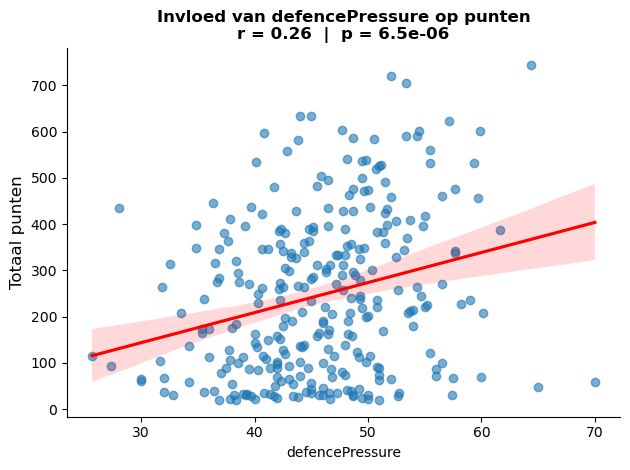

,variabele,r,p,n
1,buildUpPlayPassing,-0.280145,0.000001,288
3,defencePressure,0.262194,0.000007,288
2,chanceCreationPassing,0.174651,0.002940,288
0,buildUpPlaySpeed,0.057984,0.326806,288


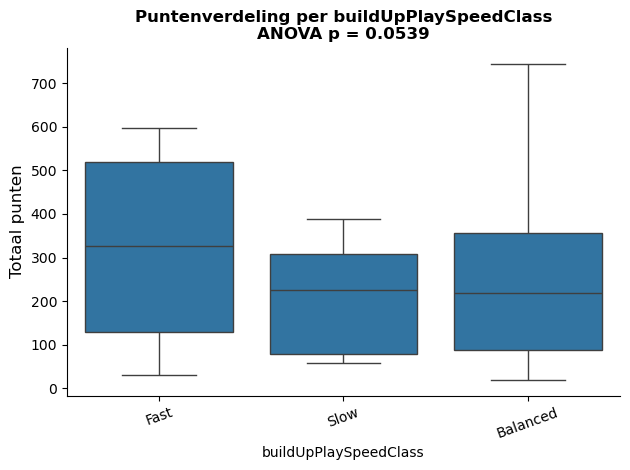

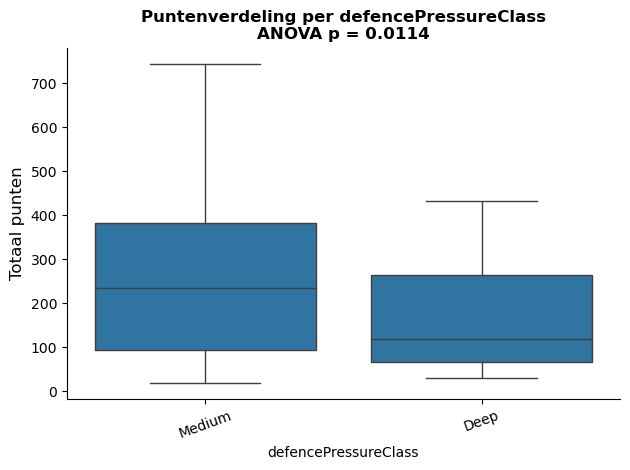

,variabele,anova_F,p,n
1,defencePressureClass,6.484923,0.011407,286
0,buildUpPlaySpeedClass,2.950375,0.053920,288


In [26]:
# Numerieke variabelen analyseren en resultaten opslaan
num_results = [plot_numeric_vs_points(data_2b, col)
               for col in num_vars if col in data_2b.columns]
num_summary = pd.DataFrame([r for r in num_results if r])

if not num_summary.empty:
    # Sorteren op sterkste correlatie (absoluut)
    num_summary = num_summary.sort_values('r', key=lambda s: s.abs(), ascending=False)
display(num_summary)

# Categoriale variabelen analyseren en resultaten opslaan
cat_results = [plot_categorical_vs_points(data_2b, col)
               for col in cat_vars if col in data_2b.columns]
cat_summary = pd.DataFrame([r for r in cat_results if r])
if not cat_summary.empty:
    cat_summary = cat_summary.sort_values('p')
display(cat_summary)


---
### 4.3 Interpretatie 

##### 4.3.1 Numerieke variabelen
Numerieken variabelen worden getoetst met een Pearson-correlatie (n = 288). De regressieplots tonen het verband tussen elke teameigenschap en het totaal aantal punten over alle seizoenen.

- **buildUpPlayPassing** heeft de sterkste correlatie: r = −0.28, p < 0.001. Teams die korter/lager passen scoren gemiddeld *meer* punten. Het verband is significant.
- **defencePressure** laat een positief verband zien: r = +0.26, p < 0.001. Hogere pressing hangt samen met meer punten. Ook significant.
- **chanceCreationPassing** heeft een zwak positief verband: r = +0.17, p = 0.003. Nog net significant, maar de spreiding in de plot is groot.
- **buildUpPlaySpeed** toont vrijwel geen verband: r = +0.06, p = 0.327. Speelsnelheid alleen voorspelt punten niet.

---

##### 4.3.2 Categoriale variabelen 
Worden getoetst met een eenweg ANOVA. De boxplots tonen de puntenverdeling per klasse.

- **defencePressureClass**: F = 6.48, p = 0.011. Er is een significant verschil tussen pressingsklassen — teams in de hogere pressingsklasse behalen aantoonbaar meer punten.
- **buildUpPlaySpeedClass**: F = 2.95, p = 0.054. Net boven de grens van p = 0.05 en daarmee niet significant. Het verschil in punten tussen snelheidsklassen kan op toeval berusten.

---
<a id='3'></a>
# **Sprint 4**

---

### Opdracht 1A - Dataset gemiddelde spelers statiestieken 

In [27]:
def bereken_speler_gemiddelden(connection, seizoen=None, sorteer_op='avg_overall_rating'):
    """
    Berekent gemiddelde attributen en identificeert keepers op basis van gk_reflexes.
    Optioneel filteren op een specifiek seizoen (bijv. '2008/2009').
    Optioneel sorteren op een specifieke kolom (standaard 'avg_overall_rating').
    Toont ook de club waar de speler speelde in dat seizoen (indien seizoen opgegeven).
    """
    query = """
    SELECT
        P.player_name AS Player,
        PA.player_api_id AS player_api_id,
        AVG(PA.overall_rating) AS avg_overall_rating,
        AVG(PA.potential) AS avg_potential,
        AVG(PA.finishing) AS avg_finishing,
        AVG(PA.dribbling) AS avg_dribbling,
        AVG(PA.sprint_speed) AS avg_sprint_speed,
        AVG(PA.stamina) AS avg_stamina,
        AVG(PA.gk_reflexes) AS avg_gk_reflexes
    FROM Player_Attributes AS PA
    JOIN Player AS P ON PA.player_api_id = P.player_api_id
    """
    
    if seizoen:
        start_year, end_year = map(int, seizoen.split('/'))
        start_date = f"{start_year}-08-01"
        end_date = f"{end_year}-05-31"
        query += f" WHERE PA.date BETWEEN '{start_date}' AND '{end_date}'"
    
    query += " GROUP BY P.player_name;"
    df = pd.read_sql(query, connection)

    if seizoen:
        # Genereer UNION ALL-query compacter met een loop
        union_parts = []
        for i in range(1, 12):
            union_parts.append(f"SELECT home_player_{i} AS player_api_id, home_team_api_id AS team_api_id FROM Match WHERE season = '{seizoen}'")
            union_parts.append(f"SELECT away_player_{i}, away_team_api_id FROM Match WHERE season = '{seizoen}'")
        
        player_team_query = " UNION ALL ".join(union_parts)
        club_query = f"""
        SELECT DISTINCT P.player_name, T.team_long_name AS Club
        FROM Player P
        INNER JOIN ({player_team_query}) AS PT 
            ON P.player_api_id = PT.player_api_id AND PT.player_api_id IS NOT NULL
        INNER JOIN Team T 
            ON PT.team_api_id = T.team_api_id
        """
        
        club_df = pd.read_sql(club_query, connection)
        club_df = club_df.drop_duplicates(subset='player_name')
        df = df.merge(club_df, left_on='Player', right_on='player_name', how='left')
        df = df.drop(columns=['player_name'], errors='ignore')

    def bepaal_rol(row):
        gk_reflexes = row['avg_gk_reflexes'] if pd.notna(row['avg_gk_reflexes']) else 0
        finishing = row['avg_finishing'] if pd.notna(row['avg_finishing']) else 0
        return 'Keeper' if gk_reflexes > 30 and gk_reflexes > finishing else 'Veldspeler'

    df['Rol'] = df.apply(bepaal_rol, axis=1)
    return df.sort_values(by=sorteer_op, ascending=False)

# Uitvoeren functie 
df_resultaat = bereken_speler_gemiddelden(connection, seizoen='2006/2007', sorteer_op='avg_overall_rating')

display(df_resultaat.head(10))

,Player,player_api_id,avg_overall_rating,avg_potential,avg_finishing,avg_dribbling,avg_sprint_speed,avg_stamina,avg_gk_reflexes,Club,Rol
3748,Gianluigi Buffon,30717,93.0,93.0,10.0,9.0,44.0,56.0,93.0,NaN,Keeper
10523,Wayne Rooney,30829,93.0,93.0,93.0,90.0,90.0,92.0,12.0,NaN,Veldspeler
3913,Gregory Coupet,39989,92.0,93.0,2.0,9.0,62.0,72.0,88.0,NaN,Keeper
5022,John Terry,30627,91.0,90.0,16.0,48.0,85.0,87.0,12.0,NaN,Veldspeler
9982,Thierry Henry,30626,91.0,93.0,95.0,94.0,92.0,86.0,13.0,NaN,Veldspeler
3118,Fabio Cannavaro,34520,91.0,92.0,17.0,52.0,83.0,83.0,11.0,NaN,Veldspeler
9012,Ronaldinho,30743,91.0,95.0,90.0,97.0,93.0,80.0,10.0,NaN,Veldspeler
381,Alessandro Nesta,30723,91.0,92.0,24.0,52.0,88.0,88.0,12.0,NaN,Veldspeler
3406,Francesco Totti,30714,90.0,92.0,82.0,91.0,89.0,84.0,11.0,NaN,Veldspeler
3468,Frank Lampard,30631,90.0,92.0,84.0,82.0,83.0,92.0,6.0,NaN,Veldspeler


---
### Opdracht 1b – Gemiddelde overall rating per team per wedstrijd

In deze stap breiden we het match dataframe uit met de gemiddelde `overall_rating` van de spelers per team per wedstrijd.

**Aanpak:**
1. We laden het match dataframe uit de database, inclusief de 22 spelerkolommen (`home_player_1` t/m `home_player_11` en `away_player_1` t/m `away_player_11`).
2. Via een zelf-gedefinieerde functie zoeken we voor elke speler-ID de bijbehorende gemiddelde `overall_rating` op uit het speler-gemiddelden dataframe van opdracht 1a.
3. Dezelfde functie wordt hergebruikt voor zowel het thuis- als het uitteam (DRY-principe).
4. Het resultaat wordt opgeslagen als twee nieuwe kolommen in het match dataframe: `home_team_avg_rating` en `away_team_avg_rating`.

In [28]:
# Kolomnamen voor thuis- en uitspelers genereren via list comprehension
home_player_cols = [f'home_player_{i}' for i in range(1, 12)]
away_player_cols = [f'away_player_{i}' for i in range(1, 12)]

print("Thuisspeler kolommen:", home_player_cols)
print("Uitspeler kolommen:", away_player_cols)

Thuisspeler kolommen: ['home_player_1', 'home_player_2', 'home_player_3', 'home_player_4', 'home_player_5', 'home_player_6', 'home_player_7', 'home_player_8', 'home_player_9', 'home_player_10', 'home_player_11']
Uitspeler kolommen: ['away_player_1', 'away_player_2', 'away_player_3', 'away_player_4', 'away_player_5', 'away_player_6', 'away_player_7', 'away_player_8', 'away_player_9', 'away_player_10', 'away_player_11']


In [29]:
# Gemiddelde spelerstatistieken ophalen uit opdracht 1a
df_spelers = bereken_speler_gemiddelden(connection)

# Opzoektabel eenmalig aanmaken buiten de functie (efficiënt)
rating_lookup = df_spelers.set_index('player_api_id')['avg_overall_rating'].to_dict()

def bereken_team_gemiddelde_rating(player_ids, rating_lookup):
    """Berekent de gemiddelde overall rating van een team op basis van speler-IDs.

    Parameters:
        player_ids (list): Lijst van player_api_id waarden voor één team in één wedstrijd.
        rating_lookup (dict): Dictionary met player_api_id als sleutel en avg_overall_rating als waarde.

    Returns:
        float: Gemiddelde overall rating van het team, of NaN als er geen ratings beschikbaar zijn.
    """
    
    # Ratings ophalen via list comprehension, ontbrekende waarden overslaan
    ratings = [rating_lookup[pid] for pid in player_ids
               if pd.notna(pid) and pid in rating_lookup]

    return np.mean(ratings) if ratings else np.nan

In [30]:
# Match dataframe opnieuw inladen met alle spelerkolommen
# Aparte variabelenaam om overschrijven door eerdere queries te voorkomen
df_match = pd.read_sql("""
    SELECT *
    FROM Match
""", connection)

print(f"Match dataframe geladen: {df_match.shape[0]} wedstrijden, {df_match.shape[1]} kolommen")

Match dataframe geladen: 25979 wedstrijden, 115 kolommen


In [31]:
# Opzoektabel eenmalig aanmaken buiten de functie (efficiënt)
rating_lookup = df_spelers.set_index('player_api_id')['avg_overall_rating'].to_dict()

# Gemiddelde rating berekenen voor thuis- en uitteam via dezelfde functie (DRY)
df_match['home_team_avg_rating'] = df_match.apply(
    lambda row: bereken_team_gemiddelde_rating(row[home_player_cols].values, rating_lookup), axis=1
)
df_match['away_team_avg_rating'] = df_match.apply(
    lambda row: bereken_team_gemiddelde_rating(row[away_player_cols].values, rating_lookup), axis=1
)

# Voeg de individuele overall rating van elke speler per club toe
home_rating_cols = [f'{col}_overall_rating' for col in home_player_cols]
away_rating_cols = [f'{col}_overall_rating' for col in away_player_cols]

df_match[home_rating_cols] = df_match[home_player_cols].replace(rating_lookup)
df_match[away_rating_cols] = df_match[away_player_cols].replace(rating_lookup)

# Toon match + individuele speler ratings per team
display(df_match[df_match['home_team_avg_rating'].notna()][
    ['match_api_id', 'season', 'home_team_api_id', 'away_team_api_id']
    + home_rating_cols + away_rating_cols
].head(10))

,match_api_id,season,home_team_api_id,away_team_api_id,home_player_1_overall_rating,home_player_2_overall_rating,home_player_3_overall_rating,home_player_4_overall_rating,home_player_5_overall_rating,home_player_6_overall_rating,...,away_player_2_overall_rating,away_player_3_overall_rating,away_player_4_overall_rating,away_player_5_overall_rating,away_player_6_overall_rating,away_player_7_overall_rating,away_player_8_overall_rating,away_player_9_overall_rating,away_player_10_overall_rating,away_player_11_overall_rating
144,493016,2008/2009,9996,8635,65.200000,NaN,63.428571,62.000000,63.083333,NaN,...,71.060606,68.958333,69.823529,72.166667,67.944444,67.450000,71.416667,69.913043,79.692308,75.333333
145,493017,2008/2009,8203,9987,63.214286,62.733333,70.151515,61.800000,69.192308,61.500000,...,71.388889,60.750000,66.750000,70.185185,69.333333,68.000000,65.000000,71.666667,64.611111,71.826087
146,493018,2008/2009,9986,9998,71.000000,NaN,NaN,70.291667,65.916667,57.666667,...,63.333333,63.000000,61.458333,56.000000,66.272727,60.454545,67.100000,63.500000,63.000000,62.545455
147,493019,2008/2009,9985,9984,NaN,72.000000,71.458333,64.333333,68.777778,68.210526,...,63.142857,62.454545,62.454545,64.700000,71.800000,67.500000,66.000000,64.625000,63.100000,67.129032
148,493020,2008/2009,9994,9991,70.666667,66.800000,63.000000,62.923077,64.250000,66.230769,...,65.956522,66.083333,66.285714,NaN,68.142857,65.800000,68.272727,78.108108,70.350000,69.423077
149,493021,2008/2009,8342,9999,71.266667,68.444444,68.142857,70.375000,69.888889,68.541667,...,59.000000,60.400000,58.333333,62.333333,NaN,58.666667,58.750000,74.928571,67.111111,61.000000
150,493022,2008/2009,9993,8571,73.304348,64.470588,NaN,64.333333,63.625000,69.500000,...,60.000000,61.600000,58.666667,NaN,66.285714,65.294118,63.250000,71.117647,72.088235,65.217391
151,493023,2008/2009,7947,4049,62.307692,66.333333,63.000000,63.157895,59.000000,65.000000,...,56.000000,61.000000,NaN,NaN,63.333333,66.666667,54.000000,63.000000,70.448276,51.666667
152,493024,2008/2009,10000,10001,67.095238,67.625000,61.750000,63.722222,63.411765,65.500000,...,68.500000,62.153846,64.083333,62.812500,72.833333,63.384615,59.600000,NaN,63.666667,63.666667
153,493025,2008/2009,9984,8342,65.050000,63.142857,62.454545,63.227273,64.625000,71.800000,...,68.142857,70.375000,69.888889,70.720000,68.444444,68.541667,71.739130,71.190476,69.714286,69.130435


---
### Opdracht 1c – Data aggregatie

In [32]:
# Functie aanmaken voor het maken van de aggegraties
def aggregeer_rating_per_team_per_seizoen(df_match):
    """
    Zet de gemiddelde overall rating per wedstrijd om naar
    een gemiddelde per team per seizoen.
    
    Parameters:
        df_match (DataFrame): Match dataframe met home/away team ratings.
    Returns:
        DataFrame met kolommen: season, team_api_id, avg_team_rating
    """
    # Onderstaand halen we de Home/Away team data op en geven we deze kolomen nieuwe algemene namen
    home = df_match[['season', 'home_team_api_id', 'home_team_avg_rating']].rename(
        columns={'home_team_api_id': 'team_api_id', 
                 'home_team_avg_rating': 'avg_team_rating'})
    
    
    away = df_match[['season', 'away_team_api_id', 'away_team_avg_rating']].rename(
        columns={'away_team_api_id': 'team_api_id', 
                 'away_team_avg_rating': 'avg_team_rating'})
    
    # We voegen de data van home en away spelende teams samen   
    combined = pd.concat([home, away])

   # Groepeer per seizoen en team api id, bereken hierover de gemiddelde rating over alle wedstrijden van dat team
    return combined.groupby(['season', 'team_api_id'])['avg_team_rating'].mean().reset_index()

df_team_ratings = aggregeer_rating_per_team_per_seizoen(df_match)
display(df_team_ratings.head(10))

# Grote van de output bekijken
rows, columns = df_team_ratings.shape
print(f"Columns: {columns}\nRows: {rows}")

,season,team_api_id,avg_team_rating
0,2008/2009,1601,61.591418
1,2008/2009,1957,62.679043
2,2008/2009,2182,68.551888
3,2008/2009,2183,63.252791
4,2008/2009,2186,60.627941
5,2008/2009,4049,61.442421
6,2008/2009,6403,66.024913
7,2008/2009,6421,67.807676
8,2008/2009,6493,59.027037
9,2008/2009,6601,63.501095


Columns: 3
Rows: 1481


---
### Opdracht 1d – Visualisaties
Maak voor 1 competitie voor 1 seizoen een visualisatie waarin je de relatie tussen het totaal aantal punten van de teams en de gemiddelde overall rating van het team laat zien. 

Eindstand met gemiddelde overall rating:


,season,team_api_id,avg_team_rating,totaal_punten,team_long_name
0,2015/2016,8640,72.018381,84,PSV
1,2015/2016,8593,70.789126,82,Ajax
2,2015/2016,10235,71.403790,63,Feyenoord
3,2015/2016,10229,67.136393,59,AZ
4,2015/2016,9908,66.406707,53,FC Utrecht
5,2015/2016,9791,65.622787,51,Heracles Almelo
6,2015/2016,8674,66.737310,50,FC Groningen
7,2015/2016,6413,65.962479,48,PEC Zwolle
8,2015/2016,8464,64.719139,46,N.E.C.
9,2015/2016,8277,67.053260,46,Vitesse


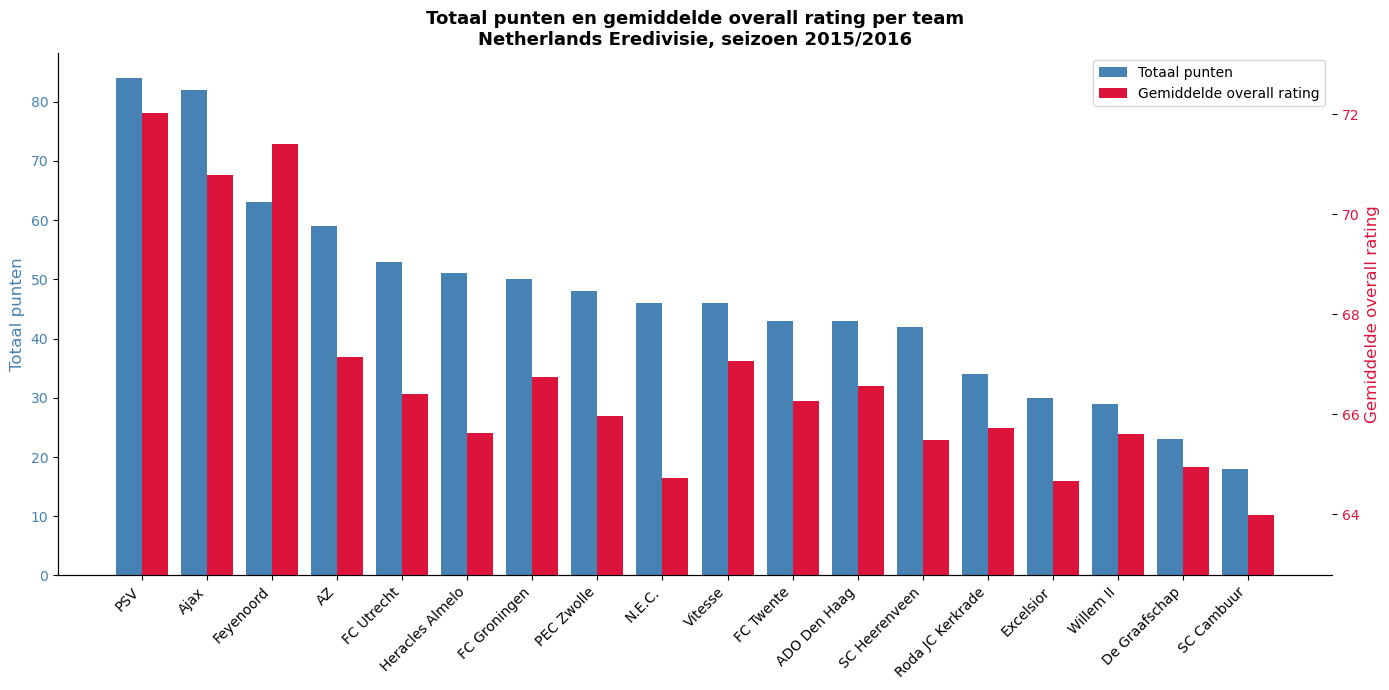

Pearson correlatie overall rating en punten: r = 0.877, p = 0.0000
Eindstand met gemiddelde sprint speed:


,season,team_api_id,avg_team_sprint_speed,totaal_punten,team_long_name
0,2015/2016,8640,72.003207,84,PSV
1,2015/2016,8593,70.520316,82,Ajax
2,2015/2016,10235,70.297123,63,Feyenoord
3,2015/2016,10229,68.683119,59,AZ
4,2015/2016,9908,68.846951,53,FC Utrecht
5,2015/2016,9791,64.012639,51,Heracles Almelo
6,2015/2016,8674,65.382210,50,FC Groningen
7,2015/2016,6413,67.786576,48,PEC Zwolle
8,2015/2016,8464,68.608601,46,N.E.C.
9,2015/2016,8277,68.458961,46,Vitesse


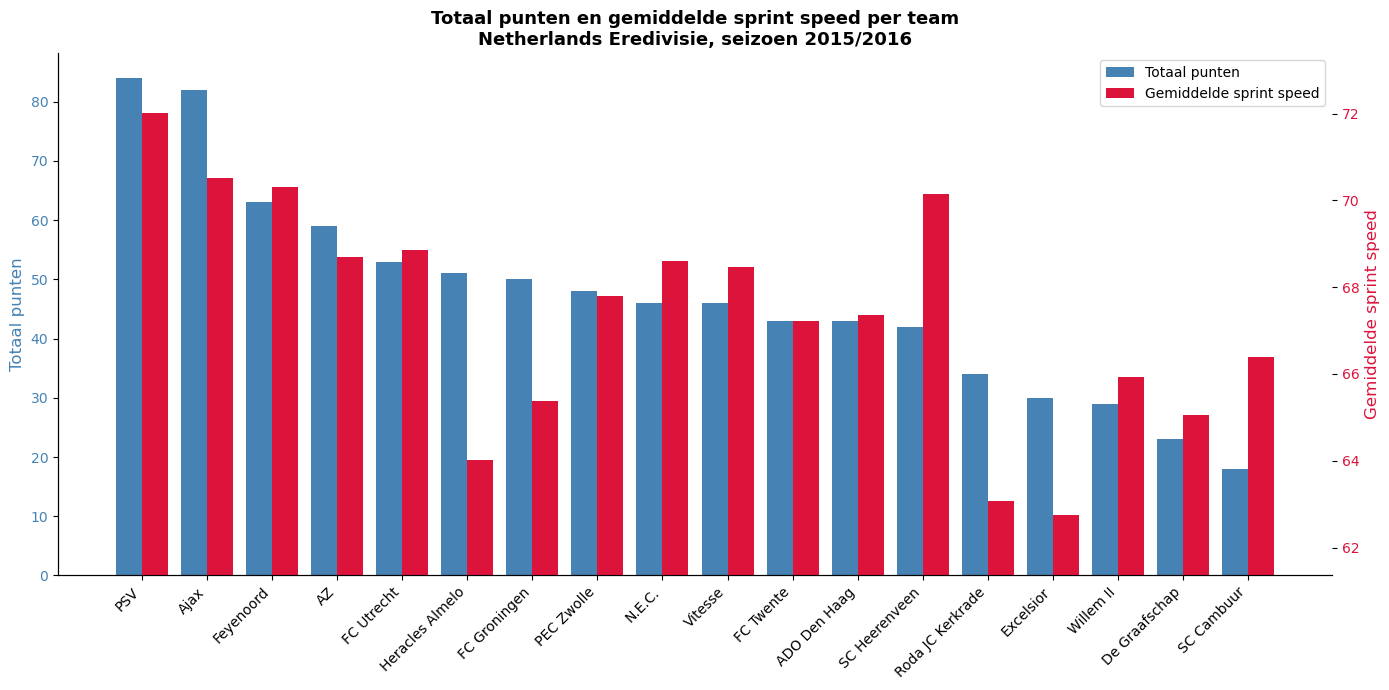

Pearson correlatie sprint speed en punten: r = 0.711, p = 0.0009


In [33]:
# Configuratie: één competitie, één seizoen
LEAGUE_ID = 13274  # Netherlands Eredivisie
LEAGUE_NAME = 'Netherlands Eredivisie'
SEIZOEN = '2015/2016'


# Voor de tweede statistiek (sprint speed) doen we de stappen uit 1b en 1c
# nog een keer, maar dan met sprint_speed in plaats van overall_rating.
# Voor overall rating gebruiken we df_team_ratings uit 1c.

df_spelers = bereken_speler_gemiddelden(connection)

# Per wedstrijd het teamgemiddelde sprint speed berekenen (zelfde aanpak als 1b)
sprint_lookup = df_spelers.set_index('player_api_id')['avg_sprint_speed'].to_dict()
df_match['home_team_avg_sprint_speed'] = df_match.apply(
    lambda r: bereken_team_gemiddelde_rating(r[home_player_cols].values, sprint_lookup), axis=1
)
df_match['away_team_avg_sprint_speed'] = df_match.apply(
    lambda r: bereken_team_gemiddelde_rating(r[away_player_cols].values, sprint_lookup), axis=1
)

# Aggregeren per team per seizoen (zelfde aanpak als aggregeer_rating_per_team_per_seizoen in 1c)
home_ss = df_match[['season', 'home_team_api_id', 'home_team_avg_sprint_speed']].rename(
    columns={'home_team_api_id': 'team_api_id',
             'home_team_avg_sprint_speed': 'avg_team_sprint_speed'})
away_ss = df_match[['season', 'away_team_api_id', 'away_team_avg_sprint_speed']].rename(
    columns={'away_team_api_id': 'team_api_id',
             'away_team_avg_sprint_speed': 'avg_team_sprint_speed'})
df_team_sprint = (pd.concat([home_ss, away_ss])
                  .groupby(['season', 'team_api_id'])['avg_team_sprint_speed']
                  .mean().reset_index())


# Beide statistieken filteren op het gekozen seizoen
df_rating_seizoen = df_team_ratings[df_team_ratings['season'] == SEIZOEN].copy()
df_sprint_seizoen = df_team_sprint[df_team_sprint['season'] == SEIZOEN].copy()


# Punten per team voor het gekozen seizoen.
df_match_sel = df_match[(df_match['league_id'] == LEAGUE_ID) &
                        (df_match['season']    == SEIZOEN)].copy()

condities_home = [df_match_sel['home_team_goal'] > df_match_sel['away_team_goal'],
                  df_match_sel['home_team_goal'] == df_match_sel['away_team_goal']]
condities_away = [df_match_sel['away_team_goal'] > df_match_sel['home_team_goal'],
                  df_match_sel['away_team_goal'] == df_match_sel['home_team_goal']]
df_match_sel['punten_home'] = np.select(condities_home, [3, 1], default=0)
df_match_sel['punten_away'] = np.select(condities_away, [3, 1], default=0)

home_p = df_match_sel[['home_team_api_id', 'punten_home']].rename(
    columns={'home_team_api_id': 'team_api_id', 'punten_home': 'punten'})
away_p = df_match_sel[['away_team_api_id', 'punten_away']].rename(
    columns={'away_team_api_id': 'team_api_id', 'punten_away': 'punten'})
df_punten = (pd.concat([home_p, away_p])
             .groupby('team_api_id')['punten'].sum()
             .reset_index()
             .rename(columns={'punten': 'totaal_punten'}))

df_teams = pd.read_sql('SELECT team_api_id, team_long_name FROM Team', connection)


def visualiseer_punten_en_statistiek(df_vis, stat_col, stat_label, seizoen, league_name):
    """Gegroepeerde bar chart per team: totaal punten en een teamstatistiek.

    Sorteert teams op totaal punten (aflopend) en toont twee bars per team,
    één voor punten en één voor de statistiek. Dual y-axis omdat de schalen
    sterk verschillen.

    Parameters:
        df_vis (DataFrame): Met kolommen team_long_name, totaal_punten en stat_col.
        stat_col (str): Naam van de statistiek-kolom.
        stat_label (str): Label voor de statistiek in legenda en y-as.
        seizoen (str): Seizoen, voor in de titel.
        league_name (str): Competitienaam, voor in de titel.
    """
    df = df_vis.sort_values('totaal_punten', ascending=False).reset_index(drop=True)
    x = np.arange(len(df))
    width = 0.4

    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Bars voor punten op linker y-as
    ax1.bar(x - width/2, df['totaal_punten'], width,
            color='steelblue', label='Totaal punten')
    ax1.set_ylabel('Totaal punten', color='steelblue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='steelblue')

    # Bars voor de statistiek op rechter y-as
    ax2 = ax1.twinx()
    ax2.bar(x + width/2, df[stat_col], width,
            color='crimson', label=stat_label)
    ax2.set_ylabel(stat_label, color='crimson', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='crimson')

    # Rechter y-as inzoomen op het bereik van de statistiek (anders zijn kleine verschillen niet zichtbaar)
    stat_min, stat_max = df[stat_col].min(), df[stat_col].max()
    marge = (stat_max - stat_min) * 0.15
    ax2.set_ylim(stat_min - marge, stat_max + marge)

    # Teamnamen onder de bars
    ax1.set_xticks(x)
    ax1.set_xticklabels(df['team_long_name'], rotation=45, ha='right')

    ax1.set_title(f'Totaal punten en {stat_label.lower()} per team\n'
                  f'{league_name}, seizoen {seizoen}', fontweight='bold', fontsize=13)

    # Beide legendes combineren in één
    lijnen1, labels1 = ax1.get_legend_handles_labels()
    lijnen2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lijnen1 + lijnen2, labels1 + labels2, loc='upper right')

    sns.despine()
    plt.tight_layout()
    plt.show()


# Visualisatie 1: gemiddelde overall rating en behaalde punten
df_vis1 = (df_rating_seizoen
           .merge(df_punten, on='team_api_id')
           .merge(df_teams, on='team_api_id'))

print('Eindstand met gemiddelde overall rating:')
display(df_vis1.sort_values('totaal_punten', ascending=False).reset_index(drop=True))

visualiseer_punten_en_statistiek(df_vis1, 'avg_team_rating',
                                  'Gemiddelde overall rating', SEIZOEN, LEAGUE_NAME)

r1, p1 = pearsonr(df_vis1['avg_team_rating'], df_vis1['totaal_punten'])
print(f'Pearson correlatie overall rating en punten: r = {r1:.3f}, p = {p1:.4f}')


# Visualisatie 2: gemiddelde sprint speed en behaalde punten
df_vis2 = (df_sprint_seizoen
           .merge(df_punten, on='team_api_id')
           .merge(df_teams, on='team_api_id'))

print('Eindstand met gemiddelde sprint speed:')
display(df_vis2.sort_values('totaal_punten', ascending=False).reset_index(drop=True))

visualiseer_punten_en_statistiek(df_vis2, 'avg_team_sprint_speed',
                                  'Gemiddelde sprint speed', SEIZOEN, LEAGUE_NAME)

r2, p2 = pearsonr(df_vis2['avg_team_sprint_speed'], df_vis2['totaal_punten'])
print(f'Pearson correlatie sprint speed en punten: r = {r2:.3f}, p = {p2:.4f}')

---
### Interpretatie

##### Visualisatie 1: gemiddelde overall rating en behaalde punten
De teams staan gesorteerd op totaal behaalde punten (aflopend). Per team zijn twee bars zichtbaar: de blauwe voor totaal punten (linker y-as) en de rode voor gemiddelde overall rating (rechter y-as, ingezoomd op het bereik). Pearson: r = 0.877, p < 0.001 (n = 18). Ongeveer 77% van de variatie in punten wordt verklaard door de gemiddelde rating.

- **PSV** (rating ≈ 72.0, 84 punten) en **Ajax** (≈ 70.7, 82 punten) staan vooraan met zowel de hoogste rating als de meeste punten. De twee bars per team volgen elkaar dus zoals verwacht.
- **AZ** (≈ 67.1, 59 punten) valt op: de blauwe puntenbar steekt relatief ver uit ten opzichte van de rode ratingbar. AZ haalde meer punten dan op basis van de spelersratings te verwachten was.
- **Feyenoord** (≈ 71.4, 63 punten) is het tegenovergestelde: de rode ratingbar is hoog (derde-hoogste van alle teams), maar de blauwe puntenbar blijft achter. Onderpresteerd ten opzichte van de spelerskwaliteit.
- **Heracles Almelo** (≈ 65.7, 51 punten) en **N.E.C.** (≈ 64.7, 46 punten) presteren eveneens beter dan hun rating doet vermoeden.
- **SC Cambuur** (≈ 64.0, 18 punten), **De Graafschap** (≈ 65.0, 23 punten) en **Willem II** (≈ 65.7, 29 punten) blijven onder verwachting.

##### Visualisatie 2: gemiddelde sprint speed en behaalde punten
Zelfde opzet, maar nu sprint speed in plaats van overall rating. Pearson: r = 0.711, p < 0.001 (n = 18). Ongeveer 50% van de variatie wordt verklaard, dus duidelijk zwakker dan bij overall rating.

- **SC Heerenveen** (≈ 70.2, 42 punten) heeft na de top drie de hoogste gemiddelde sprintsnelheid, maar eindigt in de middenmoot. De rode bar is hoog, de blauwe niet — snelheid alleen vertaalt zich hier niet naar punten.
- **Heracles Almelo** (≈ 64.1, 51 punten) is het omgekeerde: lage sprint speed, maar bovengemiddeld puntentotaal.
- **SC Cambuur** (≈ 66.4, 18 punten) is opvallend andersom: redelijke gemiddelde sprintsnelheid maar het laagste puntentotaal. Dat onderstreept dat sprint speed op zichzelf weinig zegt over eindprestatie.

##### Wat dit betekent voor de technisch directeur
Voor de Eredivisie 2015/2016 voorspelt de gemiddelde overall rating de eindstand veel beter dan de gemiddelde sprint speed (r = 0.877 vs r = 0.711). Bij scouting en contractbeslissingen is overall rating dus de betere maat van de twee. Sprint speed is op zichzelf geen sterke voorspeller en zegt vooral iets in combinatie met een specifieke speelstijl.

De interessantste teams zijn de teams waar de punten en de gemiddelde rating niet helemaal overeenkomen. AZ haalde bijvoorbeeld relatief veel punten, terwijl de gemiddelde overall rating niet bij de hoogste teams hoort. AZ deed het dus beter dan je op basis van de spelersratings zou verwachten. Bij Feyenoord zie je juist het omgekeerde: de gemiddelde rating is hoog, maar het aantal punten valt tegen. Voor een technisch directeur zijn dit nuttige signalen om verder te kijken naar dingen zoals tactiek, samenwerking binnen het team en andere factoren die niet direct in individuele ratings terugkomen.



In [34]:
matches = df_match.copy()
matches['target_resultaat'] = np.where(matches['home_team_goal'] > matches['away_team_goal'], 'win', np.where(matches['home_team_goal'] == matches['away_team_goal'], 'draw', 'loss'))

In [35]:
matches.head()


,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,away_player_5_overall_rating,away_player_6_overall_rating,away_player_7_overall_rating,away_player_8_overall_rating,away_player_9_overall_rating,away_player_10_overall_rating,away_player_11_overall_rating,home_team_avg_sprint_speed,away_team_avg_sprint_speed,target_resultaat
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,draw
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,draw
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,loss
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,win
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,loss


In [ ]:
features = list(matches.columns)

class Preprocessor:
    def __init__(self, df):
        self.df = df.copy()
    
    def preprocess(self, relevant_features):
        
        # Controleer of deze features bestaan in het dataframe
        existing_features = [f for f in relevant_features if f in self.df.columns]
        
        if not existing_features:
            raise ValueError("Geen van de relevante features zijn aanwezig in de dataframe.")
        
        # Maak een nieuwe dataframe met alleen de relevante features en het target resultaat
        processed_df = self.df[existing_features + ['target_resultaat']].dropna()
        
        return processed_df
    
    def scaling():
        pass
    
    def alg1():
        pass
    
    def alg2():
        pass
    
    def hyperparameter_tuning():
        pass
    
    
preprocessed_df = Preprocessor(matches).preprocess(features)